In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
import pandas as pd

# Read the CSV file into a pandas DataFrame
df = pd.read_csv('../../Data/fraudTrain.csv')

# Display the first few rows of the DataFrame to verify the data has been read correctly
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
# Summary statistics of the numerical columns
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [36]:
# checking for null values
df.isnull().sum().any()

False

In [38]:
# checking for duplicates
df.duplicated().any()

False

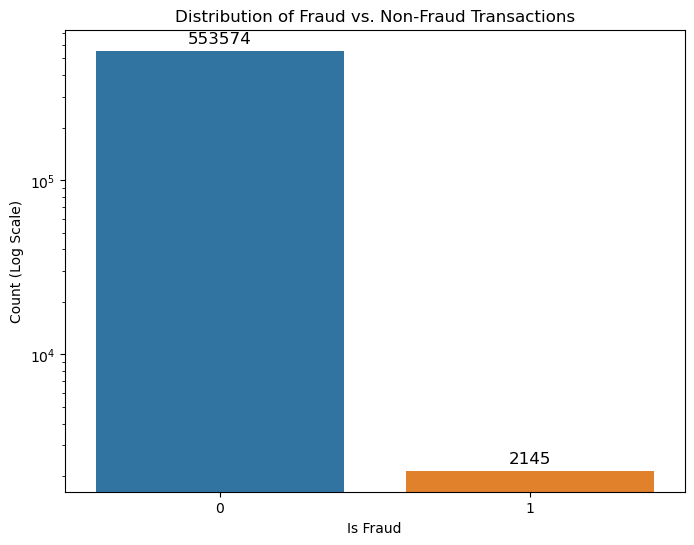

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot: Distribution of the target variable 'is_fraud'
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='is_fraud', data=df)
plt.title('Distribution of Fraud vs. Non-Fraud Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count (Log Scale)')

# Change the y-axis to log scale
ax.set_yscale('log')

# Add number of transactions on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()


In [88]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'size', 'trans_year',
       'trans_month', 'trans_day', 'trans_hour', 'age'],
      dtype='object')

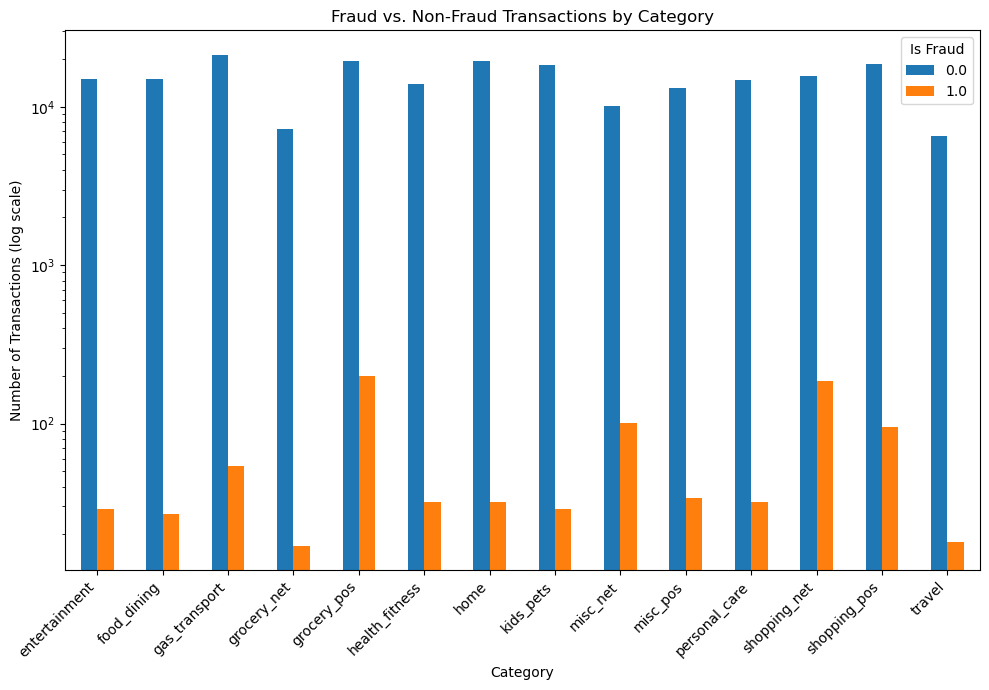

In [31]:
# Group by category and is_fraud, then count the occurrences
category_fraud_count = df.groupby(['category', 'is_fraud']).size().unstack()

# Plot the data
category_fraud_count.plot(kind='bar', figsize=(10, 7))
plt.title('Fraud vs. Non-Fraud Transactions by Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions (log scale)')
plt.yscale('log')  # Apply logarithmic scale to the y-axis
plt.legend(title='Is Fraud', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_year'] = df['trans_date_trans_time'].dt.year
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

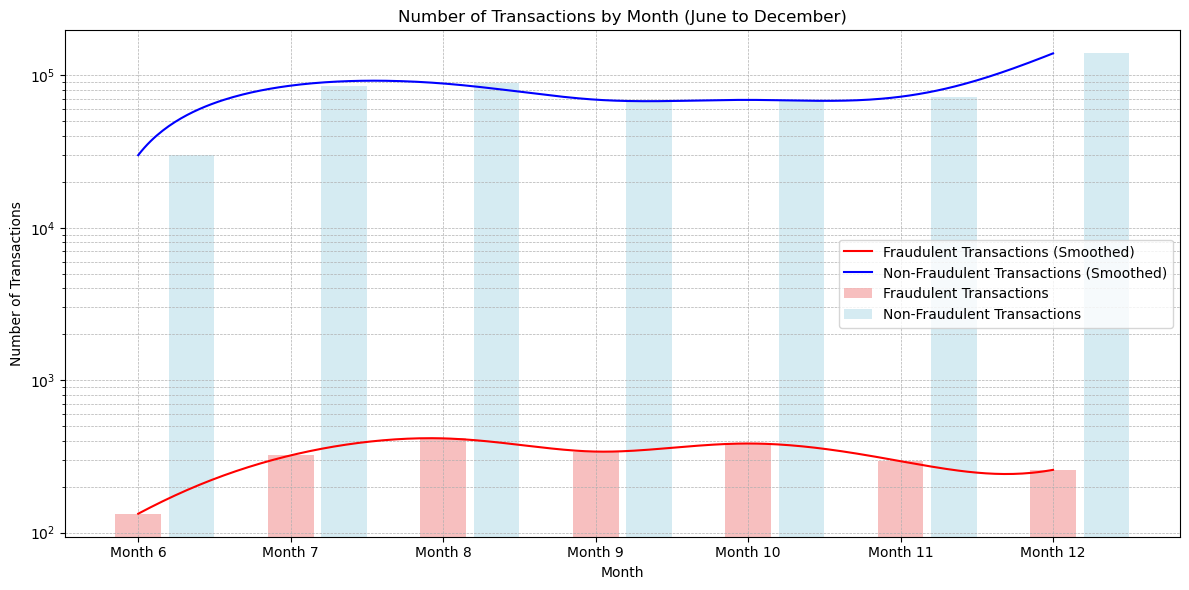

In [70]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Filter data for months 6-12
months_to_plot = [6, 7, 8, 9, 10, 11, 12]
fraudulent_df_filtered = fraudulent_df[fraudulent_df['trans_month'].isin(months_to_plot)]
non_fraudulent_df_filtered = non_fraudulent_df[non_fraudulent_df['trans_month'].isin(months_to_plot)]

# Aggregate by month
fraud_transactions_per_month = fraudulent_df_filtered.groupby(['trans_month']).size()
non_fraud_transactions_per_month = non_fraudulent_df_filtered.groupby(['trans_month']).size()

# Create x-axis values
months = np.array(months_to_plot)

# Create smoothed curves
x_months = np.linspace(months.min(), months.max(), 300)
fraud_smooth = make_interp_spline(fraud_transactions_per_month.index, fraud_transactions_per_month.values, k=3)
non_fraud_smooth = make_interp_spline(non_fraud_transactions_per_month.index, non_fraud_transactions_per_month.values, k=3)

plt.figure(figsize=(12, 6))
plt.plot(x_months, fraud_smooth(x_months), color='red', label='Fraudulent Transactions (Smoothed)')
plt.plot(x_months, non_fraud_smooth(x_months), color='blue', label='Non-Fraudulent Transactions (Smoothed)')
plt.bar(fraud_transactions_per_month.index, fraud_transactions_per_month.values, color='lightcoral', alpha=0.5, label='Fraudulent Transactions', width=0.3)
plt.bar(non_fraud_transactions_per_month.index + 0.35, non_fraud_transactions_per_month.values, color='lightblue', alpha=0.5, label='Non-Fraudulent Transactions', width=0.3)

plt.title('Number of Transactions by Month (June to December)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Format x-axis ticks
plt.xticks(months, [f'Month {i}' for i in months])
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

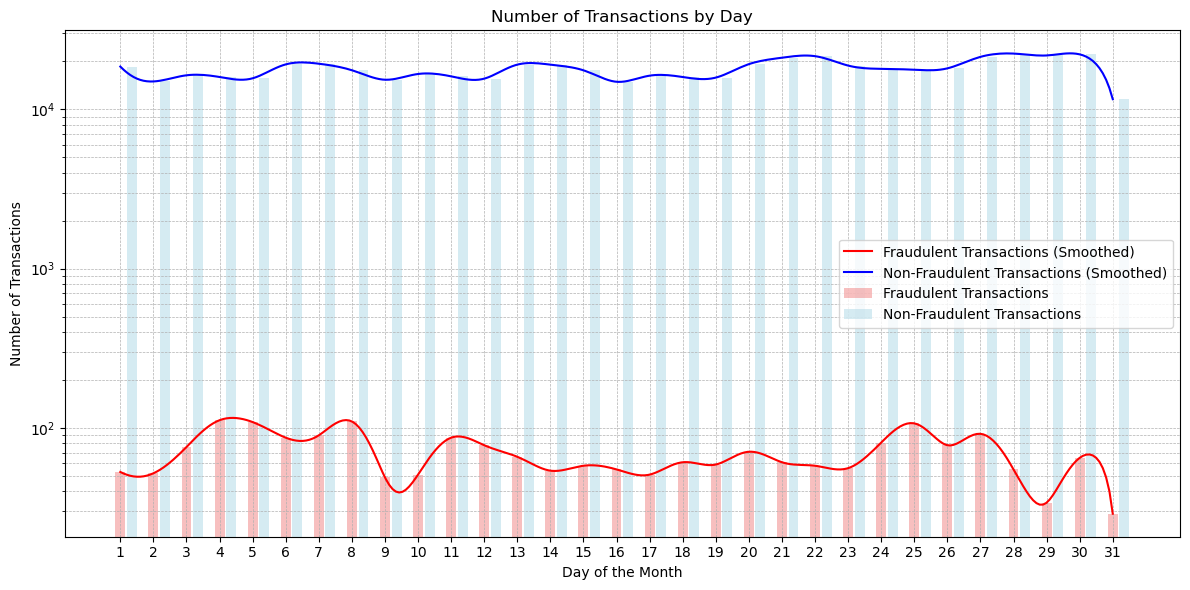

In [74]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Aggregate by day
fraud_transactions_per_day = fraudulent_df.groupby(['trans_day']).size()
non_fraud_transactions_per_day = non_fraudulent_df.groupby(['trans_day']).size()

# Create x-axis values
days = np.arange(1, 32)

# Create smoothed curves
x_days = np.linspace(days.min(), days.max(), 300)
fraud_smooth = make_interp_spline(fraud_transactions_per_day.index, fraud_transactions_per_day.values, k=3)
non_fraud_smooth = make_interp_spline(non_fraud_transactions_per_day.index, non_fraud_transactions_per_day.values, k=3)

plt.figure(figsize=(12, 6))
plt.plot(x_days, fraud_smooth(x_days), color='red', label='Fraudulent Transactions (Smoothed)')
plt.plot(x_days, non_fraud_smooth(x_days), color='blue', label='Non-Fraudulent Transactions (Smoothed)')
plt.bar(fraud_transactions_per_day.index, fraud_transactions_per_day.values, color='lightcoral', alpha=0.5, label='Fraudulent Transactions', width=0.3)
plt.bar(non_fraud_transactions_per_day.index + 0.35, non_fraud_transactions_per_day.values, color='lightblue', alpha=0.5, label='Non-Fraudulent Transactions', width=0.3)

plt.title('Number of Transactions by Day')
plt.xlabel('Day of the Month')
plt.ylabel('Number of Transactions')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Format x-axis ticks
plt.xticks(days)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

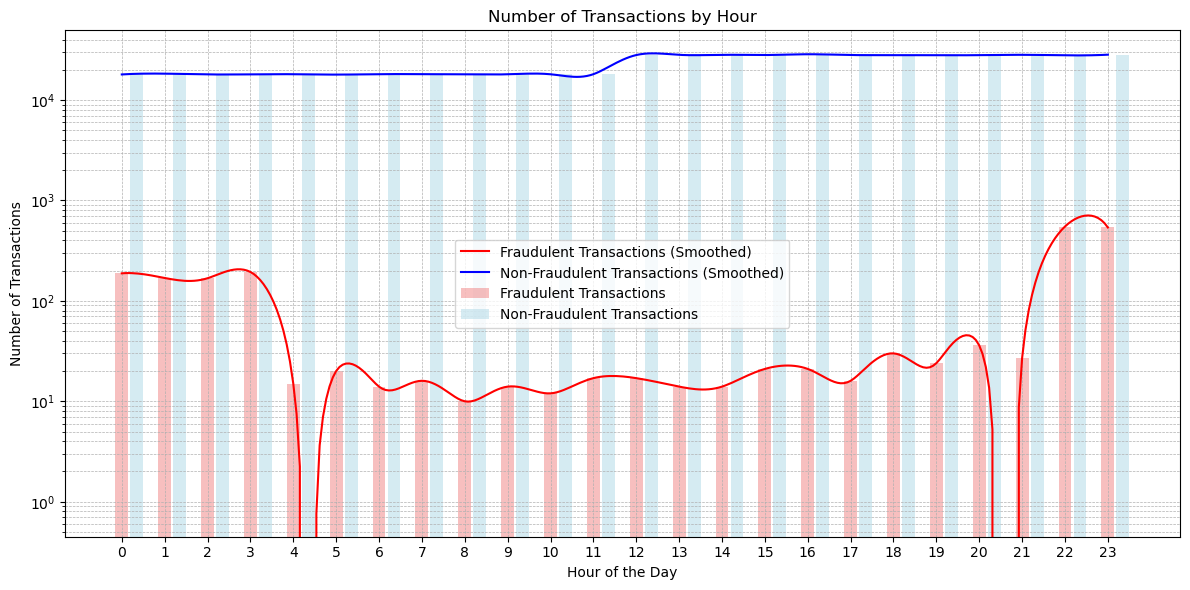

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Aggregate by hour
fraud_transactions_per_hour = fraudulent_df.groupby(['trans_hour']).size()
non_fraud_transactions_per_hour = non_fraudulent_df.groupby(['trans_hour']).size()

# Create x-axis values
hours = np.arange(0, 24)

# Create smoothed curves
x_hours = np.linspace(hours.min(), hours.max(), 300)
fraud_smooth = make_interp_spline(fraud_transactions_per_hour.index, fraud_transactions_per_hour.values, k=3)
non_fraud_smooth = make_interp_spline(non_fraud_transactions_per_hour.index, non_fraud_transactions_per_hour.values, k=3)

plt.figure(figsize=(12, 6))
plt.plot(x_hours, fraud_smooth(x_hours), color='red', label='Fraudulent Transactions (Smoothed)')
plt.plot(x_hours, non_fraud_smooth(x_hours), color='blue', label='Non-Fraudulent Transactions (Smoothed)')
plt.bar(fraud_transactions_per_hour.index, fraud_transactions_per_hour.values, color='lightcoral', alpha=0.5, label='Fraudulent Transactions', width=0.3)
plt.bar(non_fraud_transactions_per_hour.index + 0.35, non_fraud_transactions_per_hour.values, color='lightblue', alpha=0.5, label='Non-Fraudulent Transactions', width=0.3)

plt.title('Number of Transactions by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Transactions')

# Set y-axis to logarithmic scale
plt.yscale('log')

# Format x-axis ticks
plt.xticks(hours)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

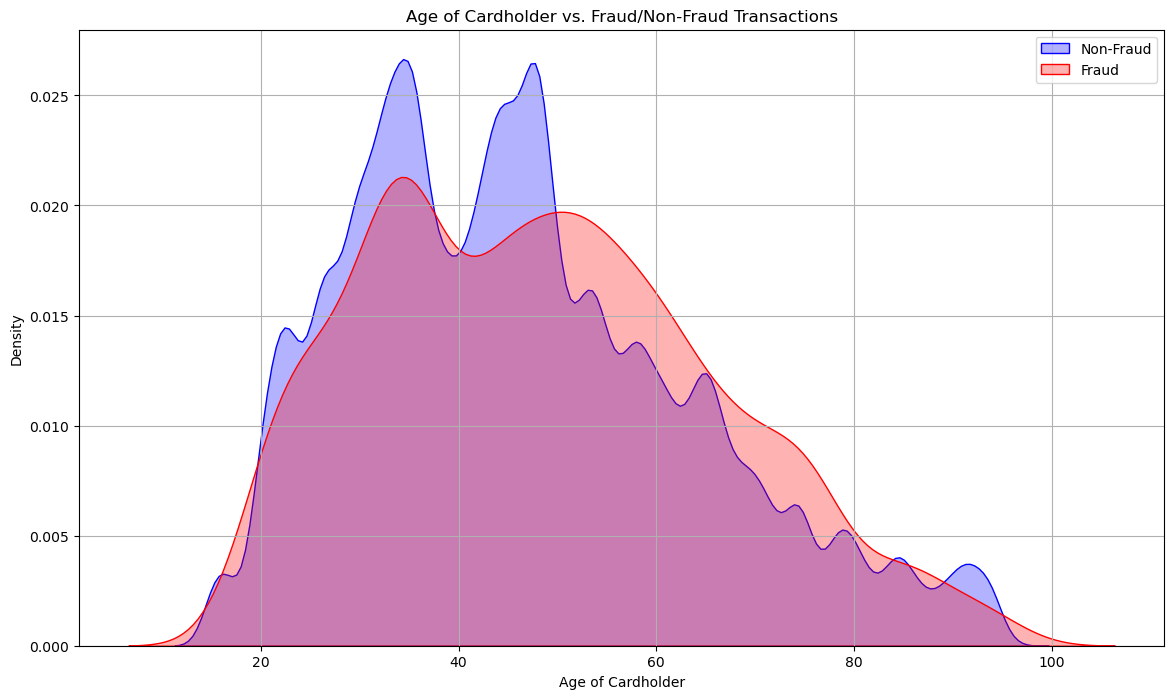

In [86]:
# Calculate the age of the cardholder
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Plot: Age vs. Fraud/Non-Fraud Transactions
plt.figure(figsize=(14, 8))

# Using a KDE plot for smooth distribution curves
sns.kdeplot(data=df[df['is_fraud'] == 0], x='age', label='Non-Fraud', color='blue', fill=True, alpha=0.3)
sns.kdeplot(data=df[df['is_fraud'] == 1], x='age', label='Fraud', color='red', fill=True, alpha=0.3)

# Add labels and title
plt.xlabel('Age of Cardholder')
plt.ylabel('Density')
plt.title('Age of Cardholder vs. Fraud/Non-Fraud Transactions')
plt.legend()
plt.grid(True)

plt.show()

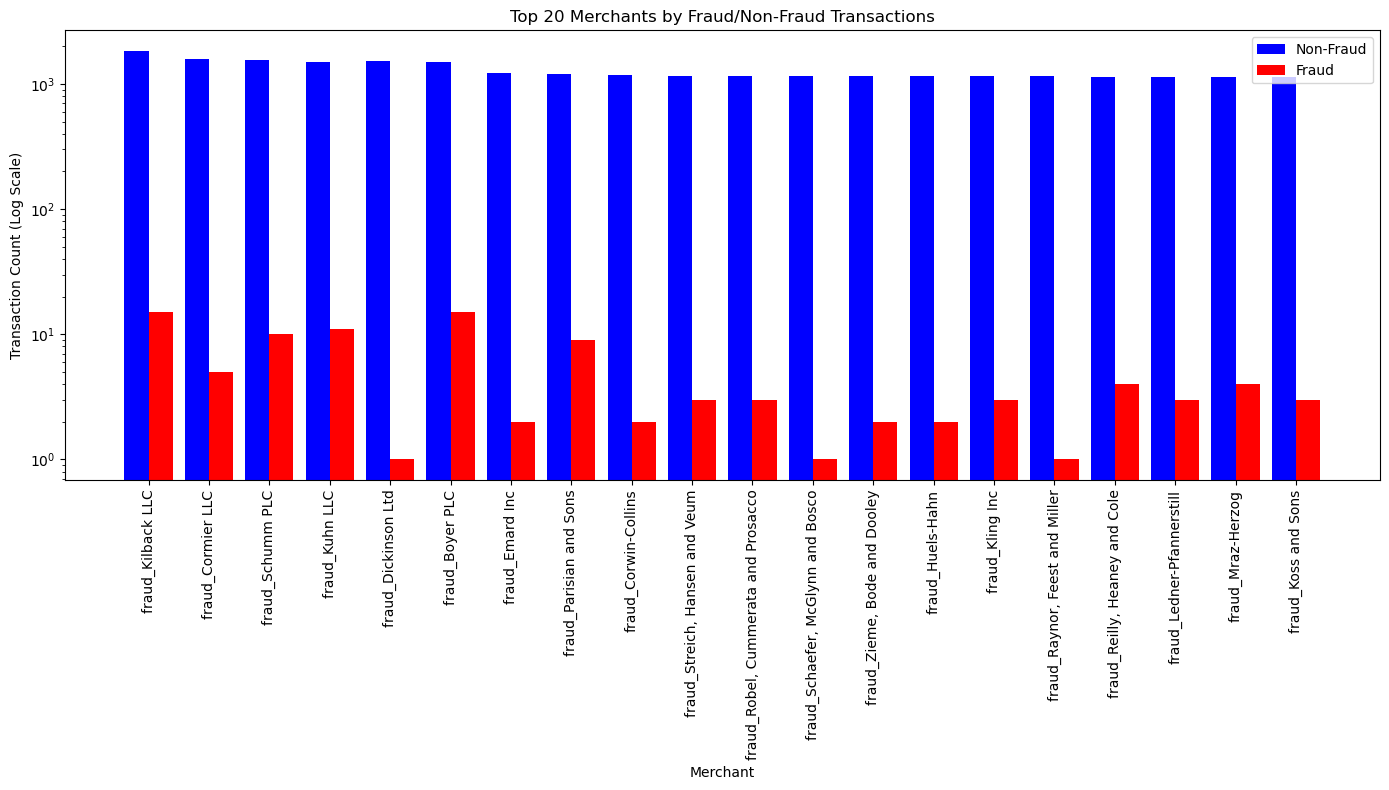

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Count transactions by merchant and fraud status
merchant_fraud_count = df.groupby(['merchant', 'is_fraud']).size().reset_index(name='transaction_count')

# Pivot the data to have fraud and non-fraud as columns
merchant_fraud_pivot = merchant_fraud_count.pivot(index='merchant', columns='is_fraud', values='transaction_count').fillna(0).reset_index()

# Calculate total transactions for each merchant and sort by it
merchant_fraud_pivot['total_transactions'] = merchant_fraud_pivot[0] + merchant_fraud_pivot[1]
merchant_fraud_pivot_sorted = merchant_fraud_pivot.sort_values(by='total_transactions', ascending=False).head(20)

# Plot the top 20 merchants
plt.figure(figsize=(14, 8))
bar_width = 0.4
index = range(len(merchant_fraud_pivot_sorted))
non_fraud_bars = plt.bar(index, merchant_fraud_pivot_sorted[0], bar_width, label='Non-Fraud', color='blue')
fraud_bars = plt.bar([i + bar_width for i in index], merchant_fraud_pivot_sorted[1], bar_width, label='Fraud', color='red')

plt.xlabel('Merchant')
plt.ylabel('Transaction Count (Log Scale)')
plt.title('Top 20 Merchants by Fraud/Non-Fraud Transactions')
plt.xticks([i + bar_width / 2 for i in index], merchant_fraud_pivot_sorted['merchant'], rotation=90)
plt.yscale('log')  # Apply log scale to the y-axis
plt.legend()

plt.tight_layout()
plt.show()


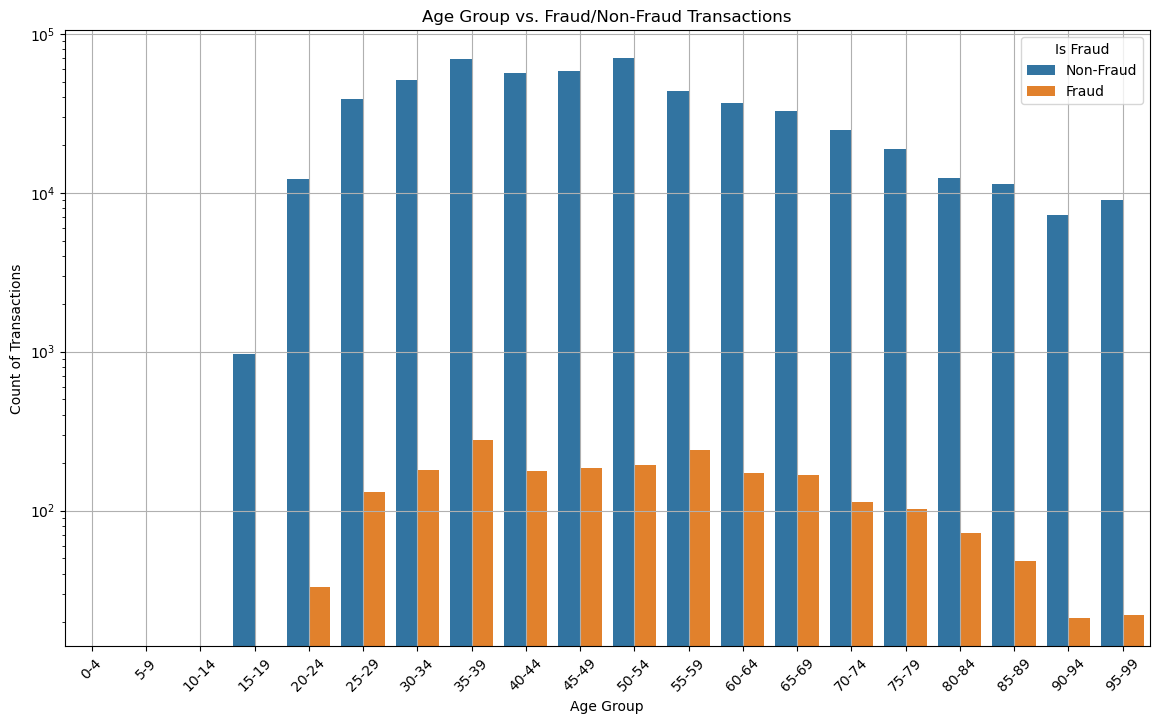

In [34]:
# Calculate age from dob
df['dob'] = pd.to_datetime(df['dob'])
current_year = pd.to_datetime('today').year
df['age'] = current_year - df['dob'].dt.year

# Create age groups with bins of 5 years
bins = range(0, 101, 5)  # Adjust the range as needed
labels = [f'{i}-{i+4}' for i in bins[:-1]]
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Plot: Age Group vs Fraud/Non-Fraud Transactions
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='age_group', hue='is_fraud')
plt.title('Age Group vs. Fraud/Non-Fraud Transactions')
plt.xlabel('Age Group')
plt.yscale('log')
plt.ylabel('Count of Transactions')
plt.xticks(rotation=45)
plt.legend(title='Is Fraud', labels=['Non-Fraud', 'Fraud'])
plt.grid(True)
plt.show()

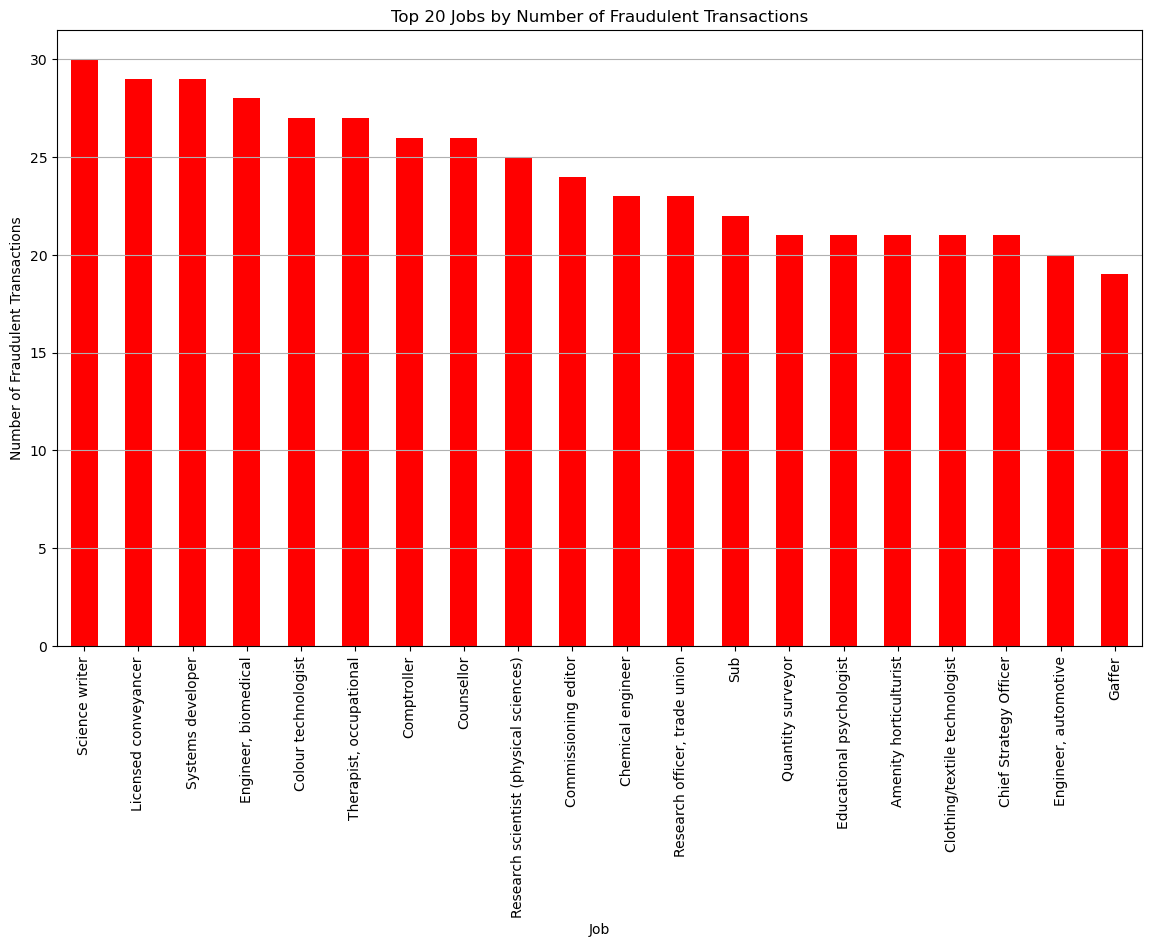

In [18]:
import matplotlib.pyplot as plt

# Filter the dataset to include only fraudulent transactions
fraud_df = df[df['is_fraud'] == 1]

# Get the top 20 jobs by fraud transaction count
top_fraud_jobs = fraud_df['job'].value_counts().head(20)

# Plot: Bar chart of top 20 jobs by fraud transaction count
plt.figure(figsize=(14, 8))
top_fraud_jobs.plot(kind='bar', color='red')
plt.title('Top 20 Jobs by Number of Fraudulent Transactions')
plt.xlabel('Job')
plt.ylabel('Number of Fraudulent Transactions')
plt.xticks(rotation=90)
plt.grid(axis='y')

plt.show()

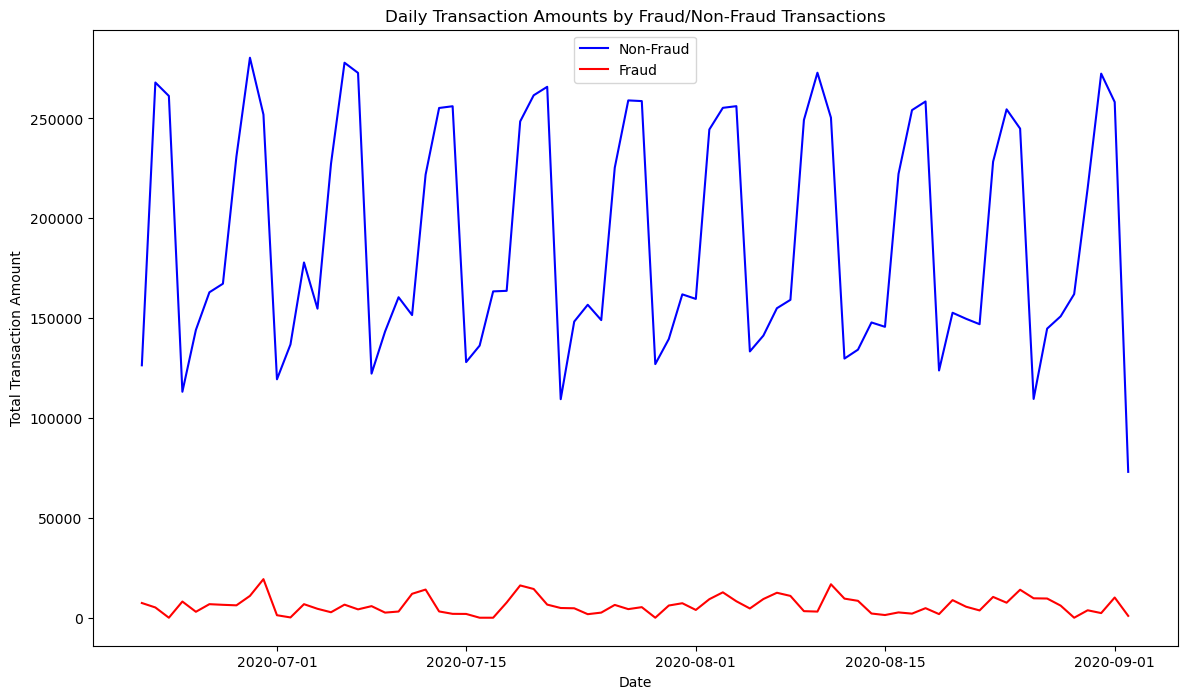

In [69]:
# Convert the transaction date to datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Resample the data by day and sum the transaction amounts for fraud and non-fraud transactions
daily_totals = df.set_index('trans_date_trans_time').groupby('is_fraud').resample('D')['amt'].sum().unstack(level=0, fill_value=0)

# Plot the data
plt.figure(figsize=(14, 8))
plt.plot(daily_totals.index, daily_totals[0], label='Non-Fraud', color='blue')
plt.plot(daily_totals.index, daily_totals[1], label='Fraud', color='red')
plt.title('Daily Transaction Amounts by Fraud/Non-Fraud Transactions')
plt.xlabel('Date')
plt.ylabel('Total Transaction Amount')
plt.legend()
plt.show()

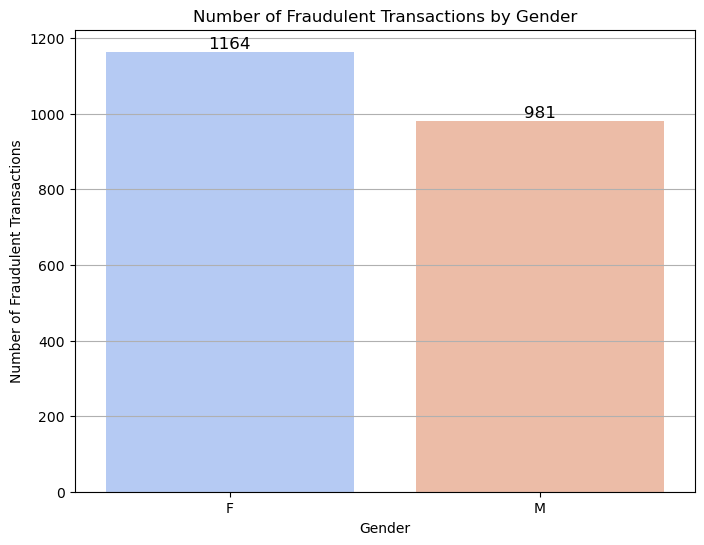

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset to include only fraudulent transactions
fraud_df = df[df['is_fraud'] == 1]

# Count the number of fraudulent transactions by gender
fraud_by_gender = fraud_df['gender'].value_counts()

# Plot: Bar chart of fraudulent transactions by gender
plt.figure(figsize=(8, 6))
sns.barplot(x=fraud_by_gender.index, y=fraud_by_gender.values, palette='coolwarm')

plt.title('Number of Fraudulent Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(axis='y')

# Display the count on top of each bar
for i in range(len(fraud_by_gender)):
    plt.text(i, fraud_by_gender.values[i] + 0.05, str(fraud_by_gender.values[i]), ha='center', va='bottom', fontsize=12)

plt.show()


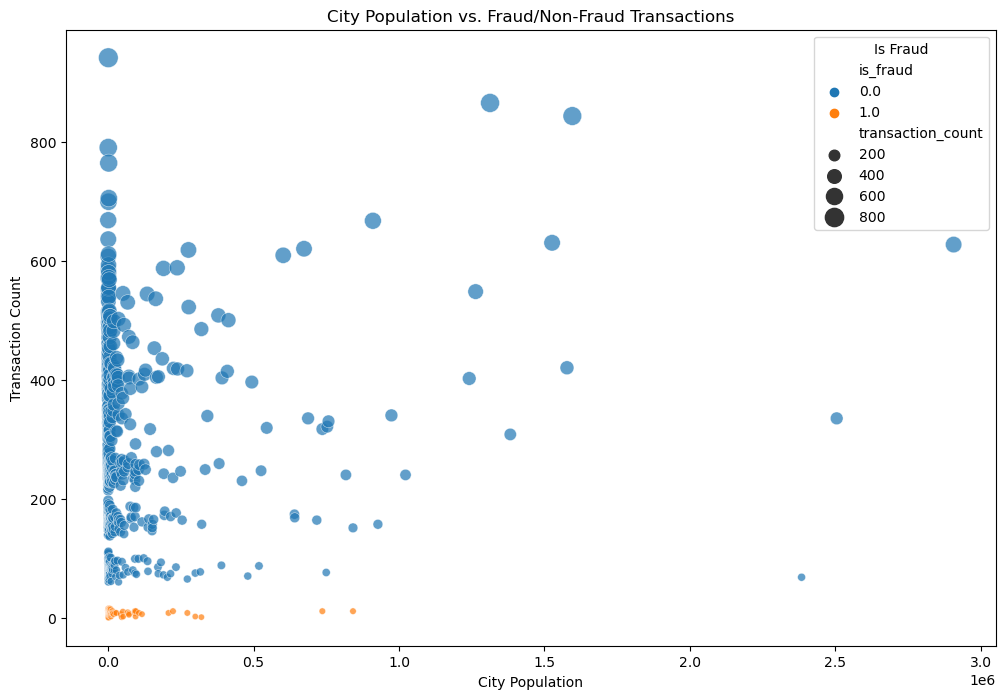

In [79]:
# Aggregate data by city population and fraud status
city_fraud_agg = df.groupby(['city_pop', 'is_fraud']).size().reset_index(name='transaction_count')

# Plot the data
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=city_fraud_agg, 
    x='city_pop', 
    y='transaction_count', 
    hue='is_fraud', 
    size='transaction_count', 
    sizes=(20, 200), 
    alpha=0.7
)
plt.title('City Population vs. Fraud/Non-Fraud Transactions')
plt.xlabel('City Population')
plt.ylabel('Transaction Count')
plt.legend(title='Is Fraud', loc='upper right')
plt.show()

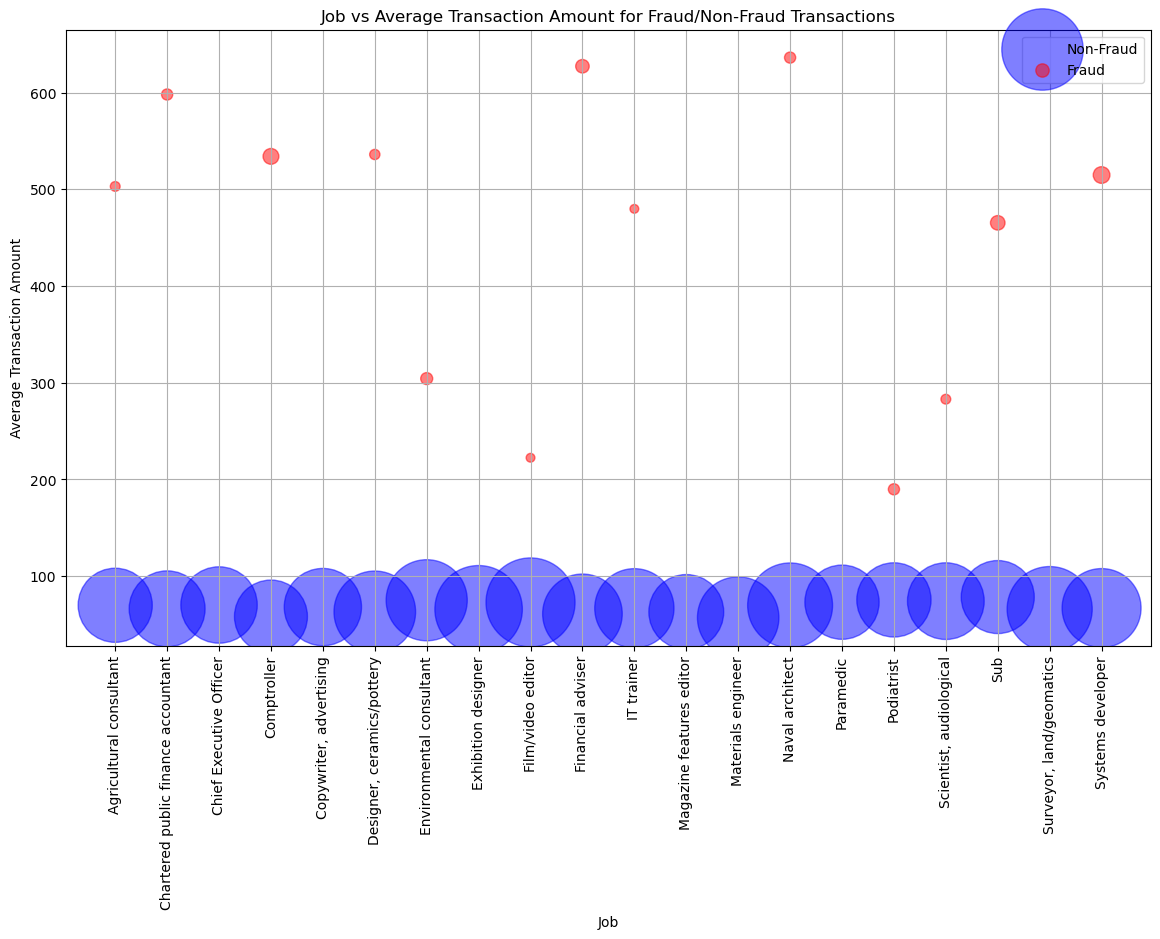

In [42]:
# Get the top 20 jobs by transaction count
top_jobs = df['job'].value_counts().head(20).index
df_top_jobs = df[df['job'].isin(top_jobs)]

# Calculate average transaction amount and transaction count for each job and fraud status
job_fraud_stats = df_top_jobs.groupby(['job', 'is_fraud']).agg({'amt': 'mean', 'job': 'count'}).rename(columns={'job': 'count'}).reset_index()

# Separate fraud and non-fraud data for plotting
non_fraud = job_fraud_stats[job_fraud_stats['is_fraud'] == 0]
fraud = job_fraud_stats[job_fraud_stats['is_fraud'] == 1]

# Plot: Bubble Chart of Job vs Average Transaction Amount for Fraud/Non-Fraud Transactions
plt.figure(figsize=(14, 8))

# Non-Fraud
plt.scatter(non_fraud['job'], non_fraud['amt'], s=non_fraud['count'], alpha=0.5, label='Non-Fraud', color='blue')

# Fraud
plt.scatter(fraud['job'], fraud['amt'], s=fraud['count']*5, alpha=0.5, label='Fraud', color='red')

plt.title('Job vs Average Transaction Amount for Fraud/Non-Fraud Transactions')
plt.xlabel('Job')
plt.ylabel('Average Transaction Amount')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

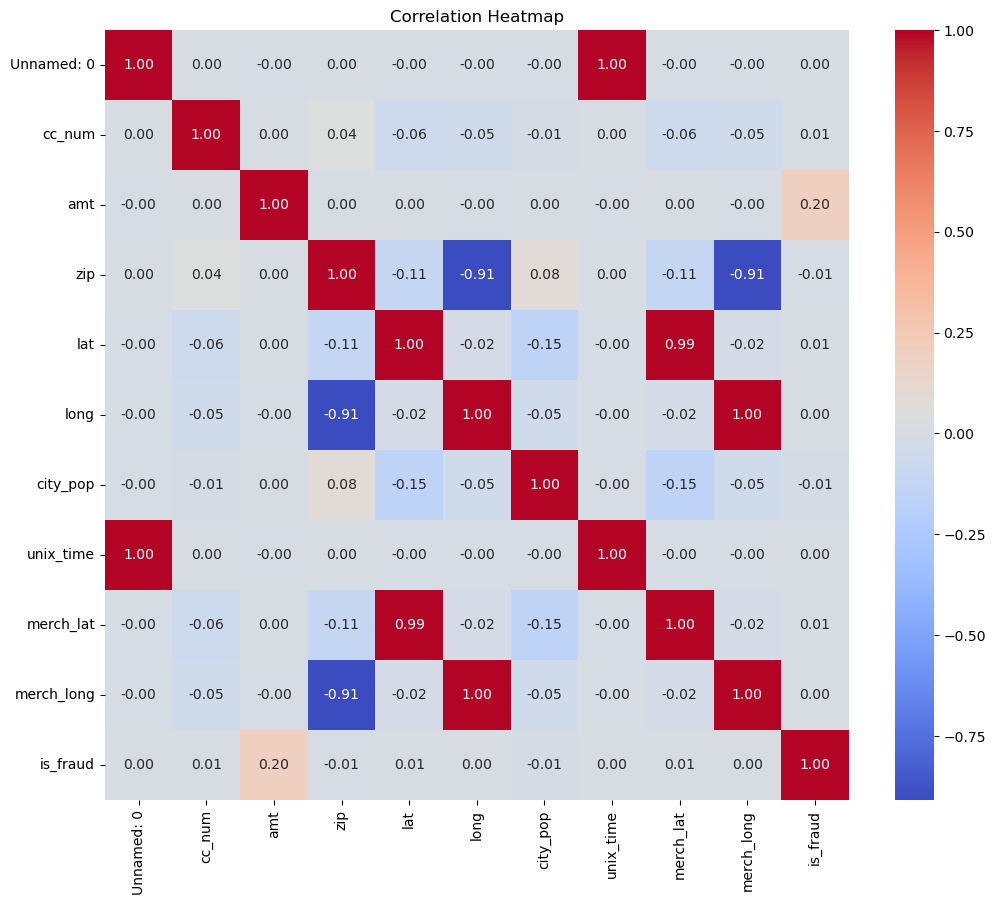

In [67]:
# Automatically select numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()

# Create the correlation heatmap
plt.figure(figsize=(12, 10))
corr = df[numerical_columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

           zip      long
zip   1.000000 -0.909942
long -0.909942  1.000000


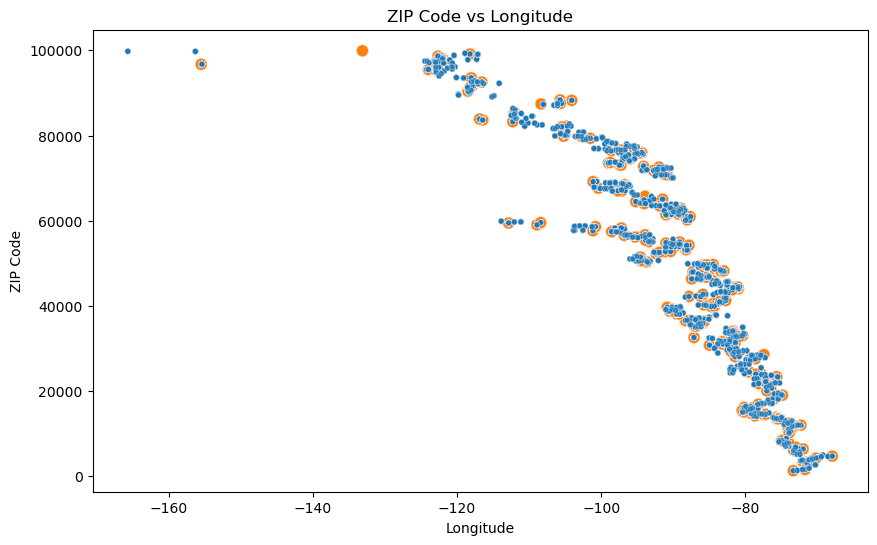

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check correlation
correlation = df[['zip', 'long']].corr()
print(correlation)

# Scatter plot to visualize the relationship
plt.figure(figsize=(10, 6))

# Define sizes for fraud and non-fraud
size_map = {0: 30, 1: 100}  # Non-fraud: 30, Fraud: 100
df['size'] = df['is_fraud'].map(size_map)

# Plot
sns.scatterplot(x='long', y='zip', data=df, hue='is_fraud', alpha=0.5, size='size', legend=None)

plt.title('ZIP Code vs Longitude')
plt.xlabel('Longitude')
plt.ylabel('ZIP Code')
plt.show()

There is a negative correlation, it means that as longitude decreases (moving west), ZIP codes tend to increase. This pattern might be expected in certain regions.

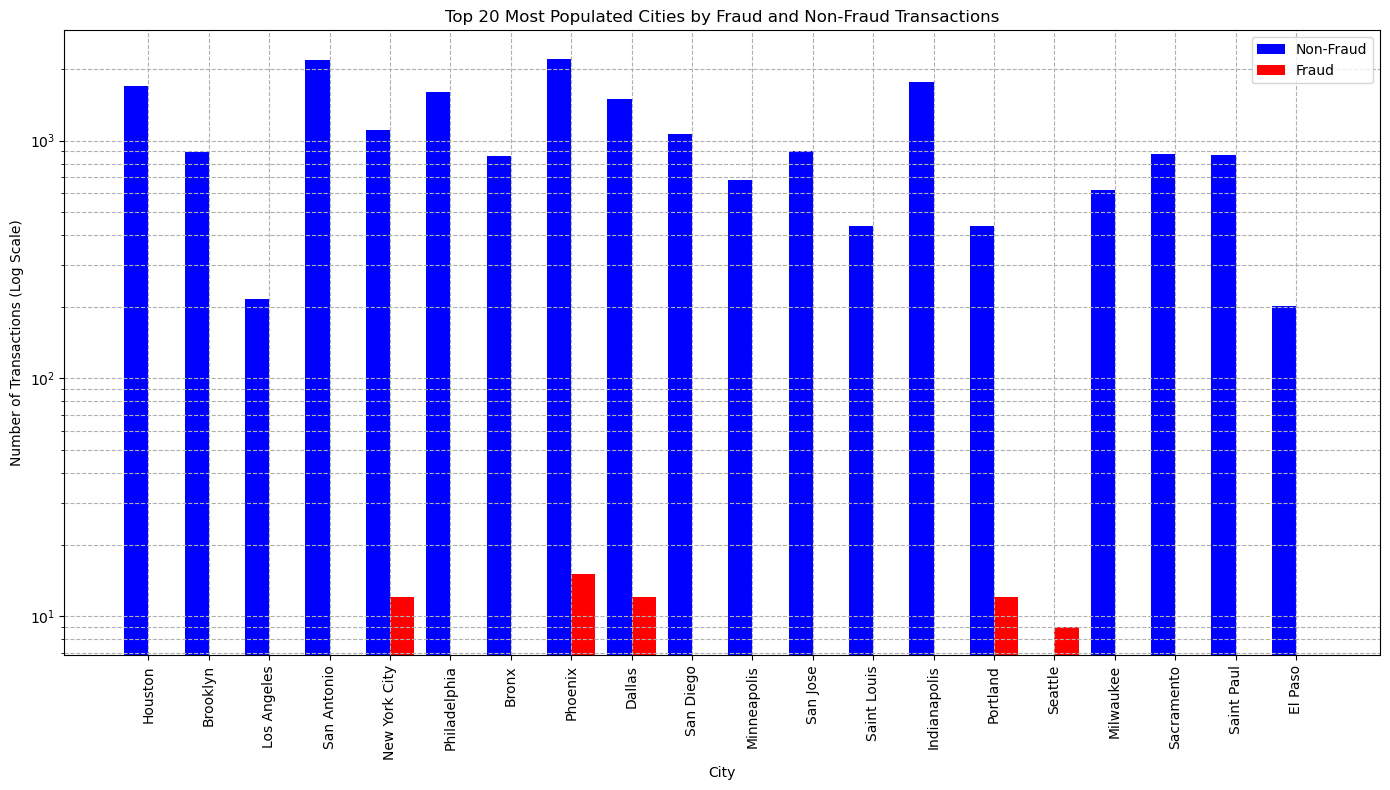

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 20 most populated cities
top_populated_cities = df.groupby('city')['city_pop'].max().nlargest(20).index
df_top_populated = df[df['city'].isin(top_populated_cities)]

# Aggregate data by city and fraud status
city_fraud_count = df_top_populated.groupby(['city', 'is_fraud']).size().unstack(fill_value=0).reset_index()

# Sort cities by population for better plotting
city_fraud_count = city_fraud_count.set_index('city').join(df_top_populated[['city', 'city_pop']].drop_duplicates().set_index('city')).reset_index()
city_fraud_count = city_fraud_count.sort_values(by='city_pop', ascending=False)

# Plot: Grouped bar chart of Fraud and Non-Fraud Transactions for Top 20 Most Populated Cities
plt.figure(figsize=(14, 8))
bar_width = 0.4
index = range(len(city_fraud_count))

# Plot bars for Non-Fraud and Fraud transactions
plt.bar(index, city_fraud_count[0], bar_width, label='Non-Fraud', color='blue')
plt.bar([i + bar_width for i in index], city_fraud_count[1], bar_width, label='Fraud', color='red')

plt.xlabel('City')
plt.ylabel('Number of Transactions (Log Scale)')
plt.title('Top 20 Most Populated Cities by Fraud and Non-Fraud Transactions')
plt.xticks([i + bar_width / 2 for i in index], city_fraud_count['city'], rotation=90)
plt.legend()
plt.yscale('log')  # Apply log scale to the y-axis
plt.grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()